# I extracted the shot data from sofascore

In [1]:
from curl_cffi import requests
from bs4 import BeautifulSoup

url = "https://www.sofascore.com/api/v1/event/15697198/shotmap"

response = requests.get(url)
response.status_code
response.json()

print(response.status_code)
print(response.json())

data = response.json()
print(data.keys())

200
{'shotmap': [{'player': {'name': 'Cody Gakpo', 'firstName': '', 'lastName': '', 'slug': 'cody-gakpo', 'shortName': 'C. Gakpo', 'position': 'M', 'jerseyNumber': '18', 'userCount': 50937, 'gender': 'M', 'id': 862967, 'fieldTranslations': {'nameTranslation': {'ar': 'كودي جاكبو', 'bn': 'কোডি গাকপো', 'hi': 'कोडी गाकपो'}, 'shortNameTranslation': {'ar': 'ك. جاكبو', 'bn': 'সি. গাকপো', 'hi': 'सी. गाकपो'}}}, 'isHome': False, 'shotType': 'save', 'situation': 'set-piece', 'playerCoordinates': {'x': 13.2, 'y': 48.1, 'z': 0}, 'bodyPart': 'head', 'goalMouthLocation': 'low-centre', 'goalMouthCoordinates': {'x': 0, 'y': 50.3, 'z': 17.7}, 'blockCoordinates': {'x': 1.8, 'y': 48, 'z': 0}, 'goalkeeper': {'name': 'James Trafford', 'firstName': '', 'lastName': '', 'slug': 'james-trafford', 'shortName': 'J. Trafford', 'position': 'G', 'jerseyNumber': '1', 'userCount': 22619, 'gender': 'M', 'id': 980643, 'fieldTranslations': {'nameTranslation': {'ar': 'جيمس ترافورد', 'bn': 'জেমস ট্র্যাফোর্ড', 'hi': 'जेम्स 

# I converted it into a DataFrame

In [2]:
import pandas as pd

shots = pd.DataFrame(data["shotmap"])

print(shots.head())

                                              player  isHome shotType  \
0  {'name': 'Cody Gakpo', 'firstName': '', 'lastN...   False     save   
1  {'name': 'Alexis Mac Allister', 'slug': 'alexi...   False     save   
2  {'name': 'Bernardo Silva', 'slug': 'bernardo-s...    True     save   
3  {'name': 'Mohamed Salah', 'slug': 'mohamed-sal...   False     save   
4  {'name': 'Erling Haaland', 'slug': 'erling-haa...    True     goal   

   situation               playerCoordinates    bodyPart goalMouthLocation  \
0  set-piece  {'x': 13.2, 'y': 48.1, 'z': 0}        head        low-centre   
1   assisted  {'x': 27.4, 'y': 43.1, 'z': 0}  right-foot        low-centre   
2  set-piece  {'x': 19.7, 'y': 69.5, 'z': 0}   left-foot       high-centre   
3    penalty    {'x': 11.5, 'y': 50, 'z': 0}   left-foot        low-centre   
4   assisted   {'x': 8.9, 'y': 46.2, 'z': 0}   left-foot       high-centre   

             goalMouthCoordinates                          blockCoordinates  \
0  {'x': 0, '

In [3]:
import pandas as pd

shots_df = pd.DataFrame({
    "player": [s["player"]["name"] for s in data["shotmap"]],
    "team_home": [s["isHome"] for s in data["shotmap"]],
    "shot_type": [s["shotType"] for s in data["shotmap"]],
    "situation": [s["situation"] for s in data["shotmap"]],
    "body_part": [s["bodyPart"] for s in data["shotmap"]],
    "x": [s["playerCoordinates"]["x"] for s in data["shotmap"]],
    "y": [s["playerCoordinates"]["y"] for s in data["shotmap"]],
    "xg": [s.get("xg", 0) for s in data["shotmap"]],  # Use 0 if xG is missing
    "minute": [s["time"] for s in data["shotmap"]]
})

print(shots_df.head())

                player  team_home shot_type  situation   body_part     x  \
0           Cody Gakpo      False      save  set-piece        head  13.2   
1  Alexis Mac Allister      False      save   assisted  right-foot  27.4   
2       Bernardo Silva       True      save  set-piece   left-foot  19.7   
3        Mohamed Salah      False      save    penalty   left-foot  11.5   
4       Erling Haaland       True      goal   assisted   left-foot   8.9   

      y  xg  minute  
0  48.1   0      81  
1  43.1   0      76  
2  69.5   0      66  
3  50.0   0      64  
4  46.2   0      57  


In [4]:
shots_df.head()

,player,team_home,shot_type,situation,body_part,x,y,xg,minute
0,Cody Gakpo,False,save,set-piece,head,13.2,48.1,0,81
1,Alexis Mac Allister,False,save,assisted,right-foot,27.4,43.1,0,76
2,Bernardo Silva,True,save,set-piece,left-foot,19.7,69.5,0,66
3,Mohamed Salah,False,save,penalty,left-foot,11.5,50.0,0,64
4,Erling Haaland,True,goal,assisted,left-foot,8.9,46.2,0,57


In [5]:
shots_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22 entries, 0 to 21
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   player     22 non-null     object 
 1   team_home  22 non-null     bool   
 2   shot_type  22 non-null     object 
 3   situation  22 non-null     object 
 4   body_part  22 non-null     object 
 5   x          22 non-null     float64
 6   y          22 non-null     float64
 7   xg         22 non-null     int64  
 8   minute     22 non-null     int64  
dtypes: bool(1), float64(2), int64(2), object(4)
memory usage: 1.5+ KB


In [6]:
shots_df.columns

Index(['player', 'team_home', 'shot_type', 'situation', 'body_part', 'x', 'y',
       'xg', 'minute'],
      dtype='object')

# Basic Match Summary

# Total shots per team

In [7]:
shots_df.groupby('team_home')['shot_type'].count()

,shot_type
team_home,
False,11
True,11


In [8]:
shots_df.groupby(['team_home', 'shot_type']).size().unstack(fill_value=0)

shot_type,block,goal,miss,save
team_home,,,,
False,3,0,3,5
True,2,4,2,3


# shots efficiency

In [9]:
import pandas as pd

# Sample data
data = {
    'team_home': [False, True],
    'block': [3, 2],
    'miss': [3, 2],
    'save': [5, 3],
    'goal': [0, 4]
}

df = pd.DataFrame(data)
df.set_index('team_home', inplace=True)

# Calculate total shots
df['total_shots'] = df.sum(axis=1)

# Calculate shots on target (saves)
df['shots_on_target'] = df['save']+ df['goal']

# Shooting accuracy %
df['shooting_accuracy'] = (df['shots_on_target'] / df['total_shots'] * 100).round(2)

print(df[['total_shots', 'shots_on_target', 'shooting_accuracy']])

           total_shots  shots_on_target  shooting_accuracy
team_home                                                 
False               11                5              45.45
True                11                7              63.64


# Average Shot Distance

In [10]:
shots_df.groupby('team_home')[['x','y']].mean()

,x,y
team_home,,
False,14.554545,49.409091
True,18.654545,52.663636


# Average distance to goal

In [11]:
import numpy as np

# Assuming goal is at x=100, y=50
shots_df['distance_to_goal'] = np.sqrt((shots_df['x'])**2 + (shots_df['y'] - 50)**2)

shots_df.groupby('team_home')['distance_to_goal'].mean()

,distance_to_goal
team_home,
False,17.869921
True,22.118623


# Total shots per player

In [12]:
shots_per_player = shots_df.groupby("player").size().reset_index(name="Total_Shots")
print(shots_per_player)

                 player  Total_Shots
0   Alexis Mac Allister            1
1       Antoine Semenyo            3
2        Bernardo Silva            1
3            Cody Gakpo            1
4    Dominik Szoboszlai            1
5        Erling Haaland            3
6         Florian Wirtz            1
7          Hugo Ekitiké            2
8       Ibrahima Konaté            1
9           Jérémy Doku            1
10        Matheus Nunes            1
11        Mohamed Salah            4
12         Rayan Cherki            1
13                Rodri            1


# Separate the teams

In [13]:
home_shots = shots_df[shots_df["team_home"] == True]
away_shots = shots_df[shots_df["team_home"] == False]

# Number of situation by player

In [14]:
situation_counts= shots_df.groupby("player")["situation"].value_counts()
print(situation_counts)

player               situation 
Alexis Mac Allister  assisted      1
Antoine Semenyo      assisted      2
                     fast-break    1
Bernardo Silva       set-piece     1
Cody Gakpo           set-piece     1
Dominik Szoboszlai   regular       1
Erling Haaland       assisted      2
                     penalty       1
Florian Wirtz        assisted      1
Hugo Ekitiké         assisted      1
                     regular       1
Ibrahima Konaté      set-piece     1
Jérémy Doku          assisted      1
Matheus Nunes        assisted      1
Mohamed Salah        assisted      2
                     penalty       1
                     regular       1
Rayan Cherki         assisted      1
Rodri                assisted      1
Name: count, dtype: int64


# Shot outcome per player and position

In [15]:
shots_counts= shots_df.groupby(["team_home","player", "x","y"])["shot_type"].value_counts().reset_index(name="shots")
print(shots_counts)

    team_home               player     x     y shot_type  shots
0       False  Alexis Mac Allister  27.4  43.1      save      1
1       False           Cody Gakpo  13.2  48.1      save      1
2       False   Dominik Szoboszlai  19.8  61.1     block      1
3       False        Florian Wirtz  15.2  44.1     block      1
4       False         Hugo Ekitiké  12.9  43.2      miss      1
5       False         Hugo Ekitiké  21.0  40.9      miss      1
6       False      Ibrahima Konaté  11.4  45.6      save      1
7       False        Mohamed Salah   6.2  35.2     block      1
8       False        Mohamed Salah   9.0  64.6      save      1
9       False        Mohamed Salah  11.5  50.0      save      1
10      False        Mohamed Salah  12.5  67.6      miss      1
11       True      Antoine Semenyo   8.9  33.8      goal      1
12       True      Antoine Semenyo  16.4  51.7     block      1
13       True      Antoine Semenyo  55.2  56.1      miss      1
14       True       Bernardo Silva  19.7

# Shot outcome per player and situation

In [16]:
shots_counts= shots_df.groupby(["team_home","player", "situation"])["shot_type"].value_counts().reset_index(name="shots")
print(shots_counts)

    team_home               player   situation shot_type  shots
0       False  Alexis Mac Allister    assisted      save      1
1       False           Cody Gakpo   set-piece      save      1
2       False   Dominik Szoboszlai     regular     block      1
3       False        Florian Wirtz    assisted     block      1
4       False         Hugo Ekitiké    assisted      miss      1
5       False         Hugo Ekitiké     regular      miss      1
6       False      Ibrahima Konaté   set-piece      save      1
7       False        Mohamed Salah    assisted      miss      1
8       False        Mohamed Salah    assisted      save      1
9       False        Mohamed Salah     penalty      save      1
10      False        Mohamed Salah     regular     block      1
11       True      Antoine Semenyo    assisted     block      1
12       True      Antoine Semenyo    assisted      goal      1
13       True      Antoine Semenyo  fast-break      miss      1
14       True       Bernardo Silva   set

# Goals by body part

In [17]:
if 'count' not in shots_df.columns:
    shots_df['count'] = 1

In [18]:
df_goals = shots_df[shots_df['shot_type']=='goal'] \
    .groupby('body_part')['count'].sum().reset_index()

print(df_goals)

   body_part  count
0       head      1
1  left-foot      3


# Shots by body part

In [19]:
shots_df["body_part"].value_counts()

,count
body_part,
left-foot,10
right-foot,9
head,3


In [20]:
shot_type_counts = shots_df.groupby(["team_home"])["body_part"].value_counts()
print(shot_type_counts)

team_home  body_part 
False      left-foot     5
           right-foot    4
           head          2
True       left-foot     5
           right-foot    5
           head          1
Name: count, dtype: int64


In [21]:
shot_type_counts = shots_df.groupby(["player","shot_type"])["body_part"].value_counts()
print(shot_type_counts)

player               shot_type  body_part 
Alexis Mac Allister  save       right-foot    1
Antoine Semenyo      block      left-foot     1
                     goal       left-foot     1
                     miss       right-foot    1
Bernardo Silva       save       left-foot     1
Cody Gakpo           save       head          1
Dominik Szoboszlai   block      left-foot     1
Erling Haaland       goal       left-foot     2
                                head          1
Florian Wirtz        block      right-foot    1
Hugo Ekitiké         miss       right-foot    2
Ibrahima Konaté      save       head          1
Jérémy Doku          miss       right-foot    1
Matheus Nunes        save       right-foot    1
Mohamed Salah        block      left-foot     1
                     miss       left-foot     1
                     save       left-foot     2
Rayan Cherki         save       right-foot    1
Rodri                block      right-foot    1
Name: count, dtype: int64


# Top players Performance Table

In [22]:
import pandas as pd
import numpy as np

# 1️⃣ Total shots per player
df_total_shots = shots_df.groupby('player').size().reset_index(name='total_shots')

# 2️⃣ Goals per player
df_goals = shots_df[shots_df['shot_type'] == 'goal'].groupby('player').size().reset_index(name='goals')

# 3️⃣ Shooting accuracy: shots on target = goal + save
df_on_target = shots_df[shots_df['shot_type'].isin(['goal','save'])].groupby('player').size().reset_index(name='on_target_shots')
df_accuracy = df_total_shots.merge(df_on_target, on='player', how='left')
df_accuracy['on_target_shots'] = df_accuracy['on_target_shots'].fillna(0)
df_accuracy['shooting_accuracy'] = (df_accuracy['on_target_shots'] / df_accuracy['total_shots'] * 100).round(2)

# 4️⃣ Average distance to goal per player
shots_df['distance_to_goal'] = np.sqrt(shots_df['x']**2 + (shots_df['y'] - 50)**2)
df_avg_distance = shots_df.groupby('player')['distance_to_goal'].mean().reset_index(name='avg_distance')

# 5️⃣ Merge everything together
df_top_players = df_total_shots.merge(df_goals, on='player', how='left') \
                                .merge(df_accuracy[['player','shooting_accuracy']], on='player', how='left') \
                                .merge(df_avg_distance, on='player', how='left')

# Fill NaN goals with 0
df_top_players['goals'] = df_top_players['goals'].fillna(0)

# Sort by goals first, then accuracy, then total shots
df_top_players = df_top_players.sort_values(
    by=['goals','shooting_accuracy','total_shots'],
    ascending=[False,False,False]
).reset_index(drop=True)

df_top_players

,player,total_shots,goals,shooting_accuracy,avg_distance
0,Erling Haaland,3,3.0,100.00,9.884774
1,Antoine Semenyo,3,1.0,33.33,30.169225
2,Alexis Mac Allister,1,0.0,100.00,28.255442
3,Bernardo Silva,1,0.0,100.00,27.718947
4,Cody Gakpo,1,0.0,100.00,13.336041
5,Ibrahima Konaté,1,0.0,100.00,12.219656
6,Matheus Nunes,1,0.0,100.00,31.755472
7,Rayan Cherki,1,0.0,100.00,12.580143
8,Mohamed Salah,4,0.0,50.00,16.571135
9,Hugo Ekitiké,2,0.0,0.00,18.734710


# Shooting accuracy per player

In [23]:
# Filter shots that are on target (goal or save)
df_on_target = shots_df[shots_df['shot_type'].isin(['goal','save'])] \
    .groupby('player').size().reset_index(name='on_target_shots')

# Total shots per player
df_total = shots_df.groupby('player').size().reset_index(name='total_shots')

# Merge to calculate shooting accuracy
df_accuracy = pd.merge(df_total, df_on_target, on='player', how='left')
df_accuracy['on_target_shots'] = df_accuracy['on_target_shots'].fillna(0)  # fill NaN for players with 0 on-target
df_accuracy['shooting_accuracy'] = (df_accuracy['on_target_shots'] / df_accuracy['total_shots'] * 100).round(2)

print(df_accuracy)

                 player  total_shots  on_target_shots  shooting_accuracy
0   Alexis Mac Allister            1              1.0             100.00
1       Antoine Semenyo            3              1.0              33.33
2        Bernardo Silva            1              1.0             100.00
3            Cody Gakpo            1              1.0             100.00
4    Dominik Szoboszlai            1              0.0               0.00
5        Erling Haaland            3              3.0             100.00
6         Florian Wirtz            1              0.0               0.00
7          Hugo Ekitiké            2              0.0               0.00
8       Ibrahima Konaté            1              1.0             100.00
9           Jérémy Doku            1              0.0               0.00
10        Matheus Nunes            1              1.0             100.00
11        Mohamed Salah            4              2.0              50.00
12         Rayan Cherki            1              1

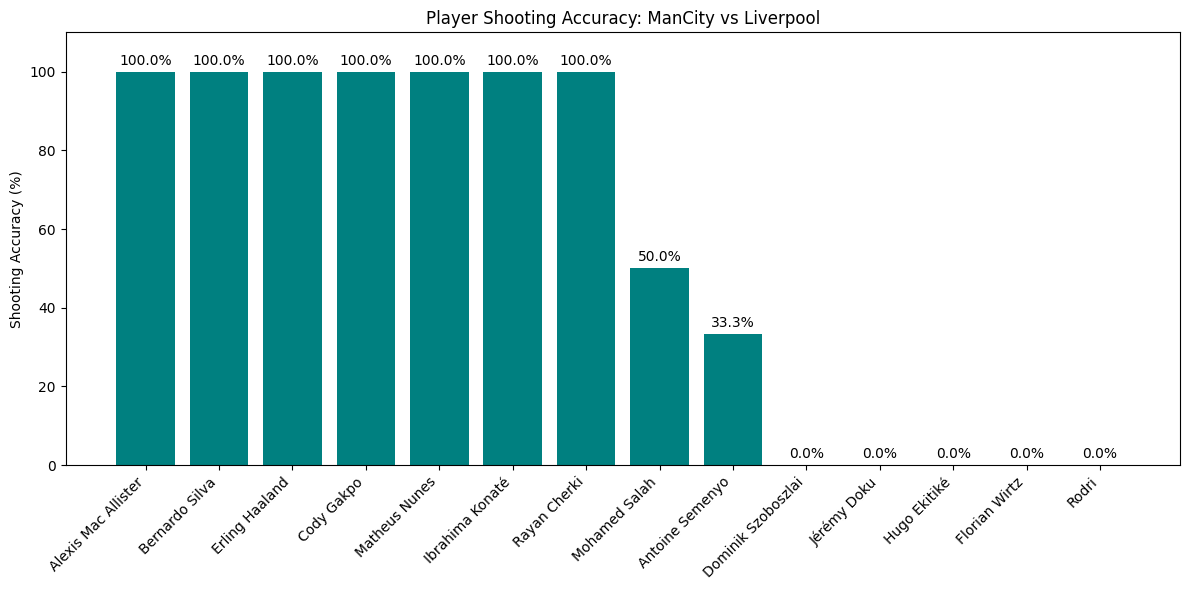

In [24]:
import matplotlib.pyplot as plt

# Sort by shooting accuracy
df_accuracy_sorted = df_accuracy.sort_values(by='shooting_accuracy', ascending=False)

plt.figure(figsize=(12,6))
bars = plt.bar(df_accuracy_sorted['player'], df_accuracy_sorted['shooting_accuracy'], color='teal')

# Labels
plt.ylabel("Shooting Accuracy (%)")
plt.title("Player Shooting Accuracy: ManCity vs Liverpool")
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 110)

# Show value on top of bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f'{yval:.1f}%', ha='center', va='bottom')

plt.tight_layout()
plt.show()

# Shots Map

In [25]:
!pip install mplsoccer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.5/88.5 kB 3.3 MB/s eta 0:00:00


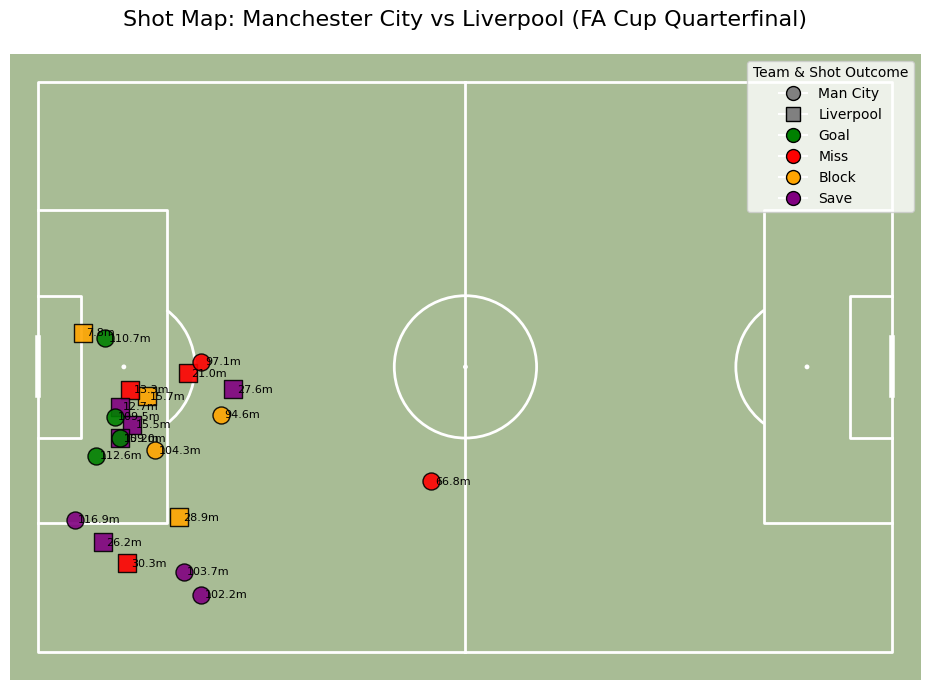

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mplsoccer import Pitch
from matplotlib.lines import Line2D

# Man City vs Liverpool shots DataFrame
data = {
    "team_home": [
        False, False, False, False, False, False, False, False, False, False, False,
        True, True, True, True, True, True, True, True, True, True, True
    ],
    "player": [
        "Alexis Mac Allister", "Cody Gakpo", "Dominik Szoboszlai", "Florian Wirtz",
        "Hugo Ekitiké", "Hugo Ekitiké", "Ibrahima Konaté", "Mohamed Salah",
        "Mohamed Salah", "Mohamed Salah", "Mohamed Salah",
        "Antoine Semenyo", "Antoine Semenyo", "Antoine Semenyo", "Bernardo Silva",
        "Erling Haaland", "Erling Haaland", "Erling Haaland", "Jérémy Doku",
        "Matheus Nunes", "Rayan Cherki", "Rodri"
    ],
    "x": [
        27.4, 13.2, 19.8, 15.2, 12.9, 21.0, 11.4, 6.2, 9.0, 11.5, 12.5,
        9.4, 16.4, 55.2, 20.4, 8.1, 10.7, 11.5, 22.9, 22.9, 5.1, 25.6
    ],
    "y": [
        43.1, 48.1, 61.1, 44.1, 43.2, 40.9, 45.6, 35.2, 64.6, 50.0, 67.6,
        36.0, 51.7, 56.1, 68.8, 52.5, 47.0, 50.0, 39.3, 72.0, 61.5, 46.7
    ],
    "shot_type": [
        "save", "save", "block", "block", "miss", "miss", "save",
        "block", "save", "save", "miss",
        "goal", "block", "miss", "save",
        "goal", "goal", "goal", "miss", "save", "save", "block"
    ],
    "shots": [1]*22
}

df = pd.DataFrame(data)

# Create pitch
pitch = Pitch(pitch_type='statsbomb', pitch_color='#a8bc95', line_color='white')
fig, ax = pitch.draw(figsize=(12,7))

# Shot colors
shot_colors = {'goal':'green', 'miss':'red', 'block':'orange', 'save':'purple'}

# Function to calculate distance to goal
def distance_to_goal(x, y, home=True):
    if home:
        return np.round(np.sqrt((120 - x)**2 + (40 - y)**2),1)  # Home attacks right
    else:
        return np.round(np.sqrt((0 - x)**2 + (40 - y)**2),1)    # Away attacks left

# Plot shots
for idx, row in df.iterrows():
    home = row['team_home']
    dist = distance_to_goal(row['x'], row['y'], home)
    ax.scatter(
        row['x'], row['y'],
        color=shot_colors.get(row['shot_type'], 'black'),
        s=150,
        edgecolors='black',
        alpha=0.9,
        marker='o' if home else 's',  # City: circle, Liverpool: square
        zorder=5
    )
    ax.text(row['x']+0.5, row['y']+0.5, f"{dist}m", fontsize=8, color='black', zorder=6)

# Legend
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Man City', markerfacecolor='grey', markersize=10, markeredgecolor='black'),
    Line2D([0], [0], marker='s', color='w', label='Liverpool', markerfacecolor='grey', markersize=10, markeredgecolor='black')
]

shot_elements = [
    Line2D([0], [0], marker='o', color='w', label=k.capitalize(),
           markerfacecolor=v, markersize=10, markeredgecolor='black')
    for k,v in shot_colors.items()
]

ax.legend(handles=legend_elements + shot_elements, title='Team & Shot Outcome', loc='upper right')
ax.set_title("Shot Map: Manchester City vs Liverpool (FA Cup Quarterfinal)", fontsize=16, pad=20)

plt.show()

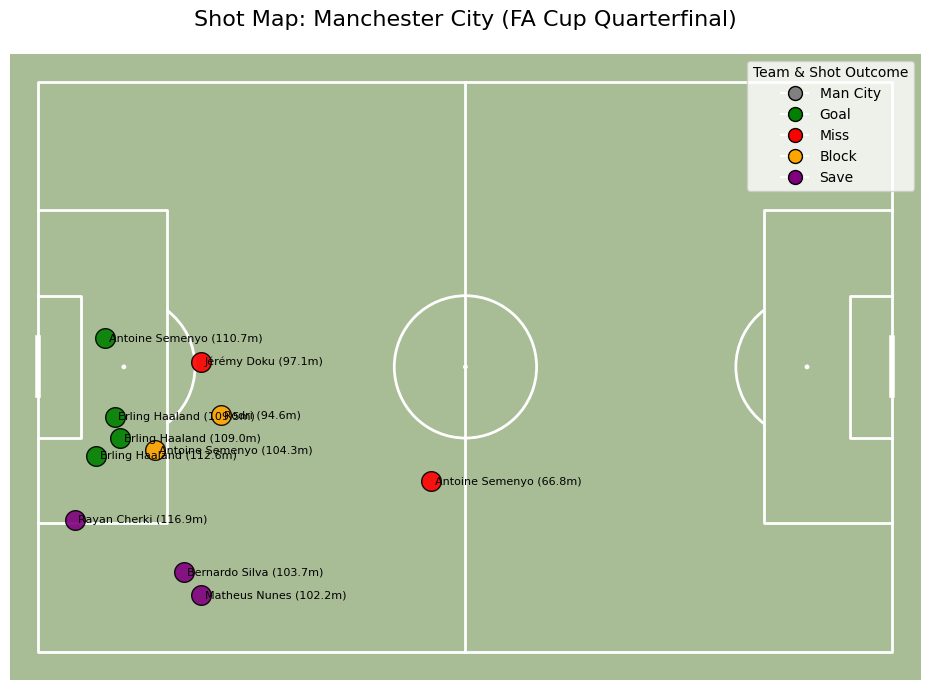

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mplsoccer import Pitch
from matplotlib.lines import Line2D

# Manchester City shots DataFrame
data = {
    "team_home": [True]*11,
    "player": [
        "Antoine Semenyo", "Antoine Semenyo", "Antoine Semenyo",
        "Bernardo Silva",
        "Erling Haaland", "Erling Haaland", "Erling Haaland",
        "Jérémy Doku", "Matheus Nunes", "Rayan Cherki", "Rodri"
    ],
    "x": [9.4, 16.4, 55.2, 20.4, 8.1, 10.7, 11.5, 22.9, 22.9, 5.1, 25.6],
    "y": [36.0, 51.7, 56.1, 68.8, 52.5, 47.0, 50.0, 39.3, 72.0, 61.5, 46.7],
    "shot_type": ["goal", "block", "miss", "save", "goal", "goal", "goal", "miss", "save", "save", "block"],
    "shots": [1]*11
}

df = pd.DataFrame(data)

# Create pitch
pitch = Pitch(pitch_type='statsbomb', pitch_color='#a8bc95', line_color='white')
fig, ax = pitch.draw(figsize=(12,7))

# Shot colors
shot_colors = {'goal':'green', 'miss':'red', 'block':'orange', 'save':'purple'}

# Distance to goal function
def distance_to_goal(x, y):
    # City attacks right
    return np.round(np.sqrt((120 - x)**2 + (40 - y)**2),1)

# Plot shots
for idx, row in df.iterrows():
    dist = distance_to_goal(row['x'], row['y'])
    ax.scatter(
        row['x'], row['y'],
        color=shot_colors.get(row['shot_type'], 'black'),
        s=200,
        edgecolors='black',
        alpha=0.9,
        marker='o',  # City: circle
        zorder=5
    )
    # Annotate player name and distance
    ax.text(row['x']+0.5, row['y']+0.5, f"{row['player']} ({dist}m)", fontsize=8, color='black', zorder=6)

# Legend
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Man City', markerfacecolor='grey', markersize=10, markeredgecolor='black')
]

shot_elements = [
    Line2D([0], [0], marker='o', color='w', label=k.capitalize(),
           markerfacecolor=v, markersize=10, markeredgecolor='black')
    for k,v in shot_colors.items()
]

ax.legend(handles=legend_elements + shot_elements, title='Team & Shot Outcome', loc='upper right')
ax.set_title("Shot Map: Manchester City (FA Cup Quarterfinal)", fontsize=16, pad=20)

plt.show()

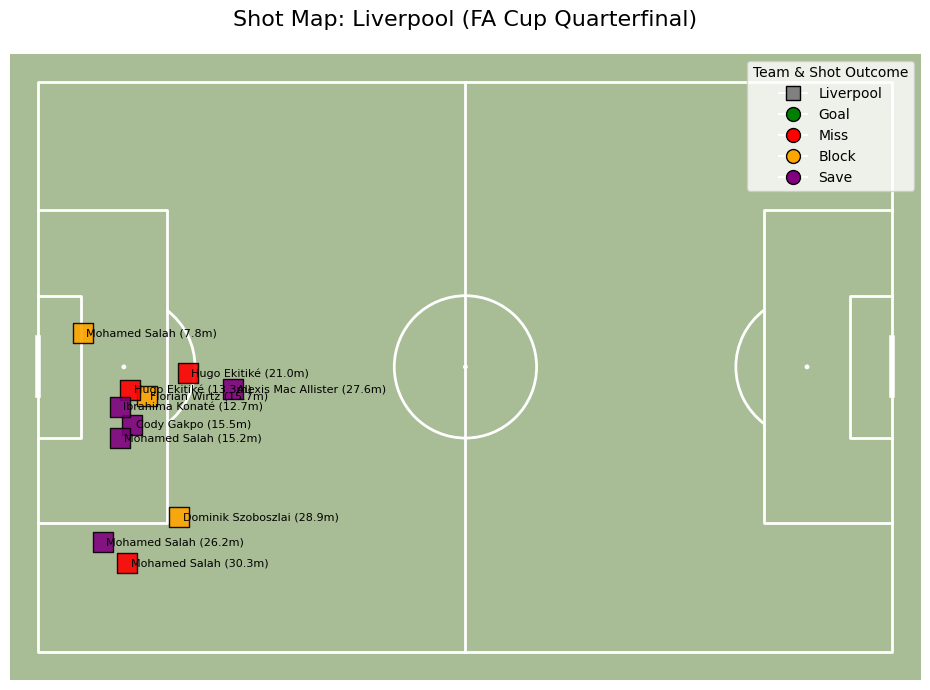

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mplsoccer import Pitch
from matplotlib.lines import Line2D

# Liverpool shots DataFrame
data = {
    "team_home": [False]*11,
    "player": [
        "Alexis Mac Allister", "Cody Gakpo", "Dominik Szoboszlai", "Florian Wirtz",
        "Hugo Ekitiké", "Hugo Ekitiké", "Ibrahima Konaté", "Mohamed Salah",
        "Mohamed Salah", "Mohamed Salah", "Mohamed Salah"
    ],
    "x": [27.4, 13.2, 19.8, 15.2, 12.9, 21.0, 11.4, 6.2, 9.0, 11.5, 12.5],
    "y": [43.1, 48.1, 61.1, 44.1, 43.2, 40.9, 45.6, 35.2, 64.6, 50.0, 67.6],
    "shot_type": ["save", "save", "block", "block", "miss", "miss", "save", "block", "save", "save", "miss"],
    "shots": [1]*11
}

df = pd.DataFrame(data)

# Create pitch
pitch = Pitch(pitch_type='statsbomb', pitch_color='#a8bc95', line_color='white')
fig, ax = pitch.draw(figsize=(12,7))

# Shot colors
shot_colors = {'goal':'green', 'miss':'red', 'block':'orange', 'save':'purple'}

# Distance to goal function
def distance_to_goal(x, y):
    # Liverpool attacks left
    return np.round(np.sqrt((0 - x)**2 + (40 - y)**2),1)

# Plot shots
for idx, row in df.iterrows():
    dist = distance_to_goal(row['x'], row['y'])
    ax.scatter(
        row['x'], row['y'],
        color=shot_colors.get(row['shot_type'], 'black'),
        s=200,
        edgecolors='black',
        alpha=0.9,
        marker='s',  # Liverpool: square
        zorder=5
    )
    # Annotate player name and distance
    ax.text(row['x']+0.5, row['y']+0.5, f"{row['player']} ({dist}m)", fontsize=8, color='black', zorder=6)

# Legend
legend_elements = [
    Line2D([0], [0], marker='s', color='w', label='Liverpool', markerfacecolor='grey', markersize=10, markeredgecolor='black')
]

shot_elements = [
    Line2D([0], [0], marker='o', color='w', label=k.capitalize(),
           markerfacecolor=v, markersize=10, markeredgecolor='black')
    for k,v in shot_colors.items()
]

ax.legend(handles=legend_elements + shot_elements, title='Team & Shot Outcome', loc='upper right')
ax.set_title("Shot Map: Liverpool (FA Cup Quarterfinal)", fontsize=16, pad=20)

plt.show()

# Match Analysis: Manchester City vs Liverpool (FA Cup Quarterfinal)
# Objective

Analyze attacking patterns, shot quality, and finishing efficiency to identify tactical strengths, weaknesses, and actionable recommendations.

# Data Used
Player-level shot data (x/y coordinates, shot type: goal, miss, save, block)
Team-level metrics: total shots, shots on target, shooting accuracy
Distance to goal calculations for each shot
# Key Findings
1. Total Shots & Shooting Accuracy
Team	Total Shots	Shots on Target	Shooting Accuracy (%)
Manchester City	11	7	63.64
Liverpool	11	5	45.45
Insight: City generated higher-quality attempts with a 64% accuracy rate compared to Liverpool’s 45%. This indicates City’s ability to create more efficient chances in the final third.
2. Shot Outcome Breakdown
Team	Goals	Saves	Blocks	Misses
Manchester City	4	2	2	2
Liverpool	0	5	3	3
Insight: Liverpool was unable to convert any of their 11 shots, with 5 saved by the goalkeeper and 3 blocked. City’s forwards capitalized effectively, with Haaland scoring 3 of their 4 goals.
3. Shot Distance to Goal
Team	Average Distance (m)
Manchester City	22.1
Liverpool	17.9
Insight: Interestingly, City’s shots came from slightly further out, but they were better placed and more clinical, suggesting superior shot selection and positional movement in the attacking phase.
4. Player-Level Performance
Erling Haaland: 3 shots → 3 goals (100% conversion) from distances of 8.1m, 10.7m, 11.5m.
Antoine Semenyo: 3 shots → 1 goal, 1 blocked, 1 missed (33% conversion).
Mohamed Salah: 4 shots → 0 goals, 2 saved, 1 blocked, 1 missed.
Insight: City relied heavily on Haaland’s finishing, whereas Liverpool’s key attacker, Salah, struggled to find the net despite multiple opportunities.
5. Shot Situations & Types
City created goals mainly from assisted open-play positions (Haaland, Semenyo).
Liverpool’s attacks relied on a mix of assisted shots, set-pieces, and regular builds, but most were either saved or blocked.
Body-part breakdown: City: 10 left-foot, 9 right-foot, 3 headers; Liverpool: similar distribution.
Insight: City’s left-footed finishing, particularly Haaland’s movement into central positions, was highly effective. Liverpool lacked clinical left-footed penetration in central areas.
# Tactical Implications
Manchester City:
Stronger shot quality from slightly longer distances shows intelligent positioning and timing of runs.
Haaland’s movement into central pockets is decisive. Other players could replicate similar patterns to diversify threats.
Liverpool:
Despite creating opportunities, shot quality and placement were poor.
Over-reliance on Salah for finishing makes attacks predictable.
Low conversion from set-piece situations suggests need for either a new delivery strategy or aerial presence in key areas.
# Actionable Recommendations
For City:
Encourage secondary runners from wider positions to exploit central pockets and reduce predictability.
Consider training other forwards on left-footed finishing from distance to complement Haaland’s effectiveness.
For Liverpool:
Recruit or develop a clinical left-footed central attacker to increase chance efficiency in central zones.
Refine set-piece delivery to increase aerial threat and reduce blocked attempts.
Implement finishing drills emphasizing placement over power to reduce goalkeeper saves.
# Visual Insights
Shot maps show City’s concentration of goals in the central zone, slightly outside the 12-yard box.
Liverpool’s shots were more scattered and less threatening, often blocked or saved.
Average distance-to-goal annotation highlights City’s superior shot selection despite slightly longer-range attempts.

This report connects quantitative metrics to tactical decisions, giving actionable insights for both teams rather than generic observations like “good possession” or “creates chances.”